# MSLR 10K Dataset visualization

In [2]:

import gdown
drive_url = "https://drive.google.com/file/d/105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY/view?usp=drive_link"
# Download the file
gdown.download(drive_url, output="mslr.zip", fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY
From (redirected): https://drive.google.com/uc?id=105jdh6AV47C0PDt7RzLZF1-u7m9Tk1oY&confirm=t&uuid=20aebf19-c167-4e73-9153-79844a31fbed
To: /content/mslr.zip
100%|██████████| 1.45G/1.45G [00:22<00:00, 64.9MB/s]


'mslr.zip'

## Extraction

In [3]:
import zipfile, os

zip_name = "mslr.zip"
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/")

print("\nExtraction complete. Contents:")


Extraction complete. Contents:


## Libsvm format inspection

In [5]:
sample_file = "/content/Fold1/train.txt"
print(f"Inspecting: {sample_file}\n")
print("─" * 80)

with open(sample_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 4:
            break

print("─" * 80)
print("""
libsvm format breakdown:
  <relevance>  qid:<query_id>  1:<f1>  2:<f2>  ...  136:<f136>

  relevance → integer label  (0(Irrelevant) to 4(perfectly relevant))
  qid       → query group id (all docs sharing a qid form one ranking list)
  1..136     → 136 pre-computed IR features + Behavioural features also (TF, IDF, BM25, PageRank, etc.)
""")

Inspecting: /content/Fold1/train.txt

────────────────────────────────────────────────────────────────────────────────
2 qid:1 1:3 2:3 3:0 4:0 5:3 6:1 7:1 8:0 9:0 10:1 11:156 12:4 13:0 14:7 15:167 16:6.931275 17:22.076928 18:19.673353 19:22.255383 20:6.926551 21:3 22:3 23:0 24:0 25:6 26:1 27:1 28:0 29:0 30:2 31:1 32:1 33:0 34:0 35:2 36:1 37:1 38:0 39:0 40:2 41:0 42:0 43:0 44:0 45:0 46:0.019231 47:0.75000 48:0 49:0 50:0.035928 51:0.00641 52:0.25000 53:0 54:0 55:0.011976 56:0.00641 57:0.25000 58:0 59:0 60:0.011976 61:0.00641 62:0.25000 63:0 64:0 65:0.011976 66:0 67:0 68:0 69:0 70:0 71:6.931275 72:22.076928 73:0 74:0 75:13.853103 76:1.152128 77:5.99246 78:0 79:0 80:2.297197 81:3.078917 82:8.517343 83:0 84:0 85:6.156595 86:2.310425 87:7.358976 88:0 89:0 90:4.617701 91:0.694726 92:1.084169 93:0 94:0 95:2.78795 96:1 97:1 98:0 99:0 100:1 101:1 102:1 103:0 104:0 105:1 106:12.941469 107:20.59276 108:0 109:0 110:16.766961 111:-18.567793 112:-7.760072 113:-20.838749 114:-25.436074 115:-14.518523 

## Exploratory Data Analysis

In [7]:
import pandas as pd
def get_file_stats(filepath):
    """Reads a libsvm file and returns basic dataset statistics."""
    doc_count = 0
    query_docs = {}
    label_counts = {0: 0, 1: 0, 2: 0, 3:0, 4:0}

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            label = int(parts[0])
            qid = parts[1].split(':')[1]

            # Update counts
            doc_count += 1
            label_counts[label] = label_counts.get(label, 0) + 1
            query_docs[qid] = query_docs.get(qid, 0) + 1

    num_queries = len(query_docs)
    avg_docs_per_query = doc_count / num_queries if num_queries > 0 else 0

    return {
        "Total Docs": doc_count,
        "Total Queries": num_queries,
        "Avg Docs/Query": avg_docs_per_query,
        "Label 0": label_counts.get(0, 0),
        "Label 1": label_counts.get(1, 0),
        "Label 2": label_counts.get(2, 0),
        "Label 3": label_counts.get(3, 0),
        "Label 4": label_counts.get(4, 0)
    }

# ── Aggregate statistics across all 5 folds (Training data) ───────────────────
base_path = "/content"
folds = [f"Fold{i}" for i in range(1, 6)]

fold_data = []
print("Gathering statistics for all 5 folds (train.txt)...\n")

for fold in folds:
    train_path = os.path.join(base_path, fold, "train.txt")
    if os.path.exists(train_path):
        stats = get_file_stats(train_path)
        stats["Fold"] = fold
        fold_data.append(stats)

# Convert to DataFrame for nice tabular display and easy plotting
stats_df = pd.DataFrame(fold_data)
# Reorder columns for readability
stats_df = stats_df[["Fold", "Total Docs", "Total Queries", "Avg Docs/Query", "Label 0", "Label 1", "Label 2", "Label 3", "Label 4"]]

display(stats_df)

Gathering statistics for all 5 folds (train.txt)...



,Fold,Total Docs,Total Queries,Avg Docs/Query,Label 0,Label 1,Label 2,Label 3,Label 4
0,Fold1,723412,6000,120.568667,377957,232569,95082,12658,5146
1,Fold2,716683,6000,119.447167,373029,230368,95117,12814,5355
2,Fold3,719111,6000,119.851833,371725,232302,96663,12903,5518
3,Fold4,718768,6000,119.794667,372756,231727,96244,12712,5329
4,Fold5,722602,6000,120.433667,377322,231874,95247,12864,5295


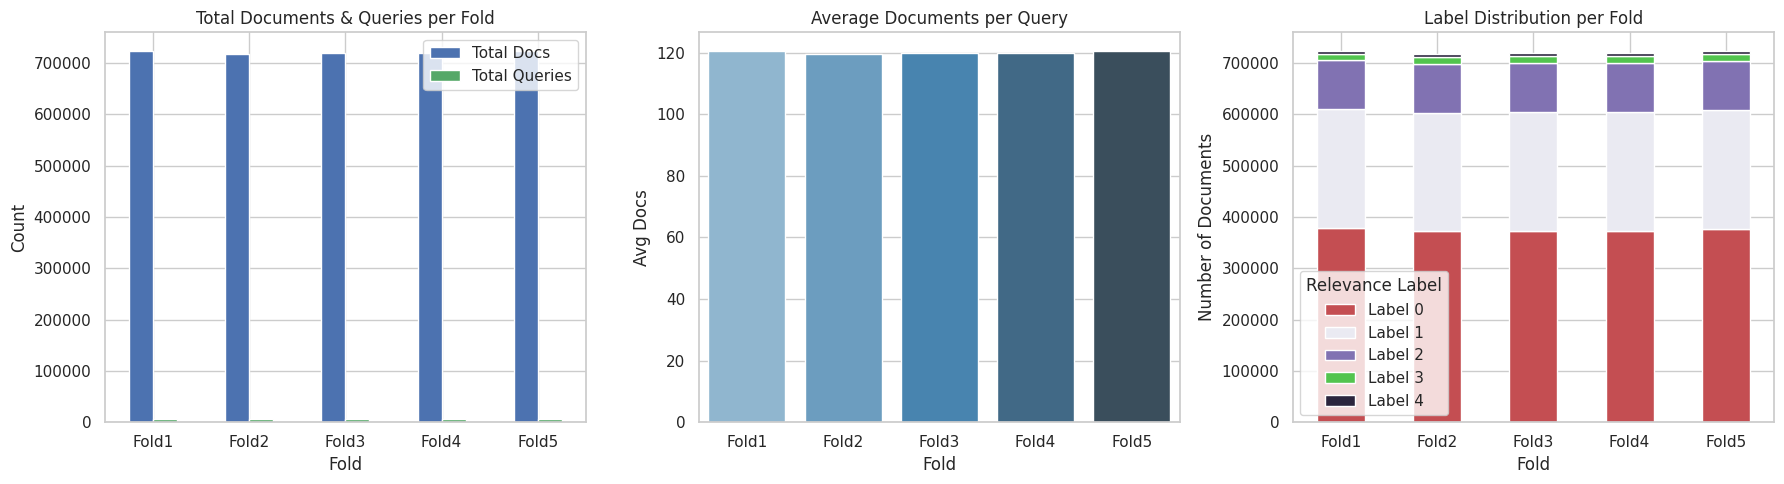

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total Documents and Queries per Fold
stats_df.plot(x="Fold", y=["Total Docs", "Total Queries"], kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Total Documents & Queries per Fold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Average Documents per Query (Fixed warning)
sns.barplot(
    data=stats_df,
    x="Fold",
    y="Avg Docs/Query",
    hue="Fold",
    ax=axes[1],
    palette="Blues_d",
    legend=False
)
axes[1].set_title("Average Documents per Query")
axes[1].set_ylabel("Avg Docs")

# Plot 3: Label Distribution (Stacked Bar)
stats_df.set_index("Fold")[["Label 0", "Label 1", "Label 2","Label 3","Label 4"]].plot(
    kind="bar", stacked=True, ax=axes[2], color=["#C44E52", "#EAEAF2", "#8172B2","#52C44E","#2B253D"]
)
axes[2].set_title("Label Distribution per Fold")
axes[2].set_ylabel("Number of Documents")
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title="Relevance Label")

plt.tight_layout()
plt.show()

In [11]:
from tqdm import tqdm
def parse_full_letor_df(filepath):
    """Parses a LETOR libsvm file fully into a Pandas DataFrame including all 46 features."""
    data = []
    with open(filepath, 'r') as f:
        for line in tqdm(f, desc=f"Loading full features from {os.path.basename(filepath)}"):
            parts = line.strip().split()
            if not parts:
                continue

            label = int(parts[0])
            qid = parts[1].split(':')[1]
            features = [float(x.split(':')[1]) for x in parts[2:138]]

            data.append([label, qid] + features)

    columns = ['label', 'qid'] + [f'F{i}' for i in range(1, 137)]
    return pd.DataFrame(data, columns=columns)

# Load full Fold 1 training data for EDA
train_df = parse_full_letor_df('/content/Fold1/train.txt')
print(f"\nLoaded {len(train_df)} rows and {len(train_df.columns)} columns.")

Loading full features from train.txt: 723412it [01:04, 11248.11it/s]



Loaded 723412 rows and 138 columns.


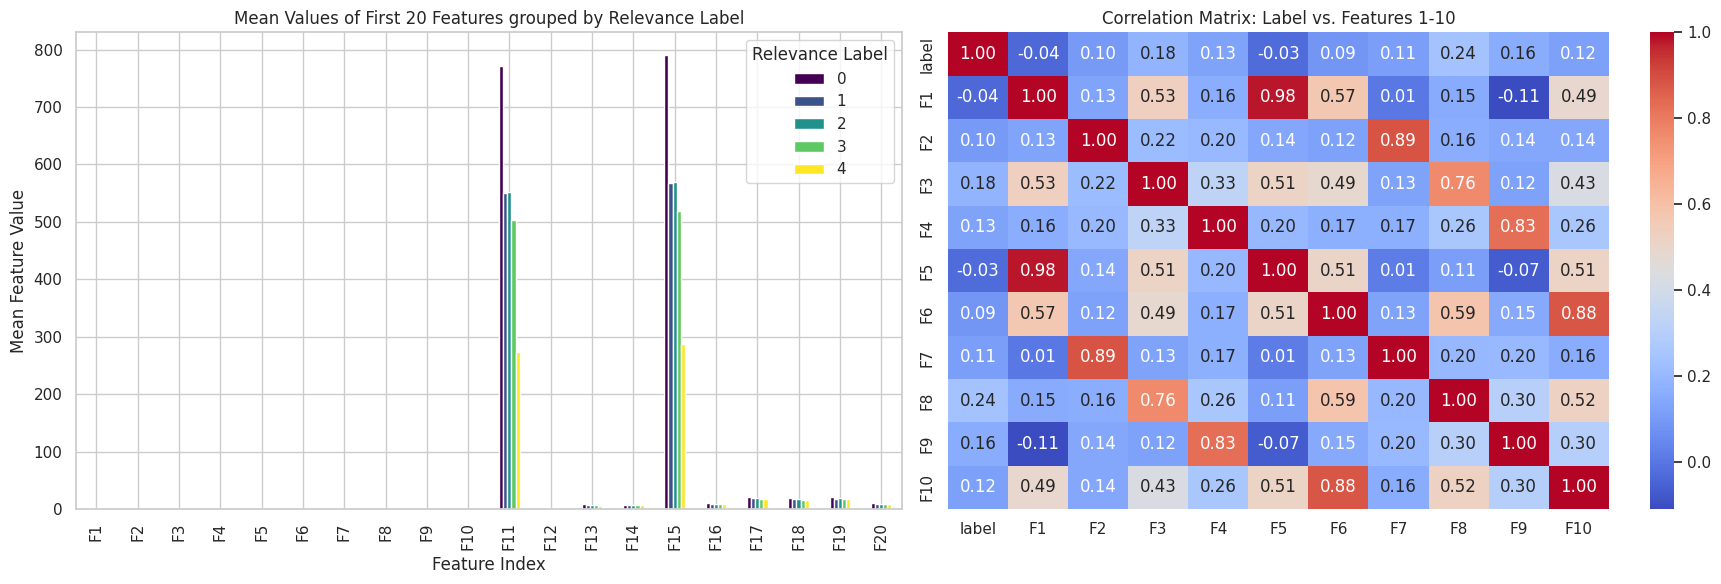

In [12]:
sns.set_theme(style="whitegrid")

# 1. Calculate the mean value of each feature grouped by label
feature_cols = [f'F{i}' for i in range(1, 47)]
mean_features_by_label = train_df.groupby('label')[feature_cols].mean().T

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Mean Feature Values per Label (showing the first 20 features to avoid clutter)
mean_features_by_label.head(20).plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title("Mean Values of First 20 Features grouped by Relevance Label")
axes[0].set_ylabel("Mean Feature Value")
axes[0].set_xlabel("Feature Index")
axes[0].legend(title='Relevance Label')

# Plot 2: Correlation Heatmap of a subset of features (e.g., F1 to F10) + Label
subset_cols = ['label'] + [f'F{i}' for i in range(1, 11)]
corr_matrix = train_df[subset_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], cbar=True)
axes[1].set_title("Correlation Matrix: Label vs. Features 1-10")

plt.tight_layout()
plt.show()

**Note** : The Data is not normalized

## Dead features and Twins

In [13]:
print("─── Automated Feature Diagnostics ───\n")

feature_cols = [f'F{i}' for i in range(1, 137)]

# 1. Find Dead Zones (Zero Variance)
# Features where the value is exactly the same for every document in the fold
variances = train_df[feature_cols].var()
dead_features = variances[variances == 0].index.tolist()

print(f"1. Dead Zones (Variance = 0.0):")
if dead_features:
    print(f"   Found {len(dead_features)} dead features: {', '.join(dead_features)}")
else:
    print("   None. All features have some variance.")

# 2. Find Twins (Highly Correlated Features)
# We flag feature pairs with a Pearson correlation > 0.98
print(f"\n2. Twins (Correlation > 0.98):")
corr_matrix = train_df[feature_cols].corr().abs()

# Use the upper triangle of the correlation matrix to avoid duplicates (e.g., F1-F5 and F5-F1)
import numpy as np
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

twins_found = False
for col in upper_tri.columns:
    # Find all rows in this column where the correlation is > 0.98
    high_corr_rows = upper_tri.index[upper_tri[col] > 0.98].tolist()
    for row in high_corr_rows:
        twins_found = True
        print(f"   {row} & {col}  -->  Correlation: {upper_tri.loc[row, col]:.4f}")

if not twins_found:
    print("   No highly correlated feature pairs found.")

─── Automated Feature Diagnostics ───

1. Dead Zones (Variance = 0.0):
   None. All features have some variance.

2. Twins (Correlation > 0.98):
   F1 & F5  -->  Correlation: 0.9812
   F11 & F15  -->  Correlation: 0.9978
   F17 & F18  -->  Correlation: 0.9915
   F17 & F19  -->  Correlation: 0.9906
   F18 & F19  -->  Correlation: 0.9878
   F16 & F20  -->  Correlation: 0.9999
   F21 & F25  -->  Correlation: 1.0000
   F26 & F30  -->  Correlation: 0.9971
   F31 & F35  -->  Correlation: 0.9952
   F36 & F40  -->  Correlation: 0.9968
   F41 & F45  -->  Correlation: 0.9828
   F21 & F71  -->  Correlation: 0.9936
   F25 & F71  -->  Correlation: 0.9937
   F22 & F72  -->  Correlation: 0.9820
   F21 & F75  -->  Correlation: 0.9925
   F25 & F75  -->  Correlation: 0.9927
   F71 & F75  -->  Correlation: 0.9998
   F76 & F80  -->  Correlation: 0.9954
   F81 & F85  -->  Correlation: 0.9939
   F86 & F90  -->  Correlation: 0.9949
   F91 & F95  -->  Correlation: 0.9968
   F111 & F115  -->  Correlation: 0.99